# Introduction: Machine Learning Part 1


__Use the provided building energy data to develop a model that can predict a building's Energy Star score, and then interpret the results to find the variables that are most predictive of the score.__

This is a supervised, regression machine learning task: given a set of data with targets (in this case the score) included, we want to train a model that can learn to map the features (also known as the explanatory variables) to the target. 


## Machine Learning Workflow

Although the exact implementation details can vary, the general structure of a machine learning project stays relatively constant: 

1. Data cleaning and formatting
2. Exploratory data analysis
3. Feature engineering and selection
4. Establish a baseline and compare several machine learning models on a performance metric

    __to be continued ...__

Setting up the structure of the pipeline ahead of time lets us see how one step flows into the other. However, the machine learning pipeline is an iterative procedure and so we don't always follow these steps in a linear fashion.  We may revisit a previous step based on results from further down the pipeline. For example, while we may perform feature selection before building any models, we may use the modeling results to go back and select a different set of features. Or, the modeling may turn up unexpected results that mean we want to explore our data from another angle. Generally, you have to complete one step before moving on to the next, but don't feel like once you have finished one step the first time, you cannot go back and make improvements! 



# Format

__Code__

fill where ever there is a missing spot like ... or your code and also be carful about null values!

__Questions__

Write your answer with enough explanation   

## Imports
 
We will use the standard data science and machine learning libraries: `numpy`, `pandas`, and `scikit-learn`. We also use `matplotlib` and `seaborn` for visualization. 

In [1]:
# Pandas and numpy for data manipulation
import pandas as pd
import numpy as np

# No warnings about setting value on copy of slice
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', 60)

# Matplotlib visualization
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 24
from IPython.core.pylabtools import figsize

# Seaborn for visualization
import seaborn as sns

# Splitting data into training and testing
from sklearn.model_selection import train_test_split

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data Cleaning and Formatting

## Load in the Data and Examine

We will be loading our data into a pandas dataframe, one of the most useful data structures for data science. Think of it as a spreadsheet within Python that we can easily manipulate, clean, and visualize. [Pandas has many methods](http://pandas.pydata.org/pandas-docs/stable/) to help make the data science/machine learning pipeline as smooth as possible.

In [2]:
# Read in data into a dataframe 
data = pd.read_csv('Energy_and_Water.csv')

# Display top of dataframe
data.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,Postal Code,Street Number,Street Name,Borough,DOF Gross Floor Area,Primary Property Type - Self Selected,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use Type,2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type,3rd Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,Metered Areas (Energy),Metered Areas (Water),ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Fuel Oil #1 Use (kBtu),Fuel Oil #2 Use (kBtu),Fuel Oil #4 Use (kBtu),Fuel Oil #5 & 6 Use (kBtu),Diesel #2 Use (kBtu),District Steam Use (kBtu),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),Electricity Use - Grid Purchase (kBtu),Weather Normalized Site Electricity (kWh),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,Not Available,10017,675,3 AVENUE,Manhattan,289356.0,Office,Office,Office,293447,Not Available,Not Available,Not Available,Not Available,1963,2,100,Whole Building,Not Available,Not Available,305.6,303.1,37.8,Not Available,614.2,Not Available,Not Available,Not Available,Not Available,Not Available,5.15506751E7,Not Available,Not Available,38139374.2,1.10827705E7,6962.2,0,6962.2,762051,Not Available,Not Available,619.4,05/01/2017 05:32:03 PM,No,In Compliance,40.750791,-73.973963,6.0,4.0,88.0,Turtle Bay-East Midtown ...
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,Not Available,10032,180,FT WASHINGTON AVENUE,Manhattan,3693539.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),3889181,Not Available,Not Available,Not Available,Not Available,1969,12,100,Whole Building,Whole Building,55,229.8,228.8,24.8,2.4,401.1,Not Available,1.96248472E7,Not Available,Not Available,Not Available,-3.914148026E8,933073441,9330734.4,332365924,9.62613121E7,55870.4,51016.4,4854.1,3889181,Not Available,Not Available,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.841402,-73.942568,12.0,10.0,251.0,Washington Heights South ...
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,Not Available,10032,3975,BROADWAY,Manhattan,152765.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),231342,Not Available,Not Available,Not Available,Not Available,1924,1,100,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,0,0,0,231342,Not Available,Not Available,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840427,-73.940249,12.0,10.0,251.0,Washington Heights South ...
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,177 Fort Washington Ave,10032,161,FT WASHINGTON AVENUE,Manhattan,891040.0,Hos

Taking a look at the raw data, we can already see a number of issues we'll have to solve. First of all, there are 60 columns and we don't know what many of them mean! All we know from the problem statement is that we want to predict the number in the `score` column. Some of the other column definitions can be reasonably guessed, but others are difficult to understand .In machine learning, this isn't actually a problem, because we let the model decide which features are important. Sometimes we may not even be given column names or told what we are predicting. Nonetheless,  to understand the problem to the extent possible, and because we also want to interpret the model results, it would be a good idea to have some knowledge of the columns. 

 we can get to [this pdf document](http://www.nyc.gov/html/gbee/downloads/misc/nyc_benchmarking_disclosure_data_definitions_2017.pdf) that details the meaning of every column. 

While we don't need to study every column, it would be a good idea to at least understand the target we want to predict. Here is the definition for the `score` target:

    A 1-to-100 percentile ranking for specified building types, calculated in Portfolio Manager, based on self-reported energy usage for the reporting year.
    
That seems pretty straightforward: the Energy Star Score is a method of ranking buildings in terms of energy efficiency with 1 the worst and 100 the best. It is a relative percentile ranking which means buildings are scored relative to one another and should display a uniform distribution across the range of values.

## Data Types and Missing Values

The `dataframe.info` method is a quick way to assess the data by displaying the data types of each column and the number of non-missing values. Already from looking at the dataframe, there might be a problem because the missing values are coded as "Not Available" rather than as `np.nan` (not a number). This means the columns with numbers will not be represented as numeric because pandas converts columns with any strings values into columns of all strings.

In [3]:
# See the column data types and non-missing values
display(data.describe())
data.info()

,Order,Property Id,DOF Gross Floor Area,Year Built,Number of Buildings - Self-reported,Occupancy,Property GFA - Self-Reported (ft²),Latitude,Longitude,Community Board,Council District,Census Tract
count,11746.000000,1.174600e+04,1.162800e+04,11746.000000,11746.000000,11746.000000,1.174600e+04,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000
mean,7185.759578,3.642958e+06,1.732695e+05,1948.738379,1.289971,98.762557,1.673739e+05,40.754379,-73.957057,7.140673,15.771275,4977.596647
std,4323.859984,1.049070e+06,3.367055e+05,30.576386,4.017484,7.501603,3.189238e+05,0.080120,0.046337,3.954129,15.674375,13520.422990
min,1.000000,7.365000e+03,5.002800e+04,1600.000000,0.000000,0.000000,0.000000e+00,40.516065,-74.243582,1.000000,1.000000,1.000000
25%,3428.250000,2.747222e+06,6.524000e+04,1927.000000,1.000000,100.000000,6.699400e+04,40.707226,-73.984662,4.000000,4.000000,100.000000
50%,6986.500000,3.236404e+06,9.313850e+04,1941.000000,1.000000,100.000000,9.408000e+04,40.759130,-73.962810,7.000000,9.000000,201.000000
75%,11054.500000,4.409092e+06,1.596140e+05,1966.000000,1.000000,100.000000,1.584140e+05,40.817623,-73.932443,9.000000,33.000000,531.500000
max,14993.000000,5.991312e+06,1.354011e+07,2019.000000,161.000000,100.000000,1.421712e+07,40.912869,-73.715543,56.000000,51.000000,155101.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11746 entries, 0 to 11745
Data columns (total 60 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11746 non-null  int64  
 1   Property Id                                                 11746 non-null  int64  
 2   Property Name                                               11746 non-null  object 
 3   Parent Property Id                                          11746 non-null  object 
 4   Parent Property Name                                        11746 non-null  object 
 5   BBL - 10 digits                                             11735 non-null  object 
 6   NYC Borough, Block and Lot (BBL) self-reported              11746 non-null  object 
 7   NYC Building Identification Number (BIN)                    11746 non-null  object 
 

Sure enough, there are a number of columns with numbers that have been recorded as `object` datatypes. These will have to be converted to `float` datatype before we can do any numerical analysis. 

### Convert Data to Correct Types

We convert the columns with numbers into numeric data types by replacing the "Not Available" entries with `np.nan` which can be interpreted as floats. Then we will convert the columns that contain numeric values (such as square feet or energy usage) into numeric datatypes. 

In [4]:
# Replace 'Not Available' with np.nan in all columns where the data type is object (string)
data = data.apply(lambda x: x.replace("Not Available", np.nan) if x.dtype == 'object' else x)

# Convert columns that are object type (after replacing 'Not Available' with np.nan) to float
data = data.apply(pd.to_numeric, errors='ignore')

# Check the data types of the columns
print(data.dtypes)

Order                                                           int64
Property Id                                                     int64
Property Name                                                  object
Parent Property Id                                             object
Parent Property Name                                           object
BBL - 10 digits                                                object
NYC Borough, Block and Lot (BBL) self-reported                 object
NYC Building Identification Number (BIN)                       object
Address 1 (self-reported)                                      object
Address 2                                                      object
Postal Code                                                    object
Street Number                                                  object
Street Name                                                    object
Borough                                                        object
DOF Gross Floor Area

C:\Users\niush\AppData\Local\Temp\ipykernel_2988\60937269.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


In [5]:
# Check the number of missing values (np.nan) in each column
print(data.isnull().sum())

Order                                                             0
Property Id                                                       0
Property Name                                                     0
Parent Property Id                                                0
Parent Property Name                                              0
BBL - 10 digits                                                  11
NYC Borough, Block and Lot (BBL) self-reported                   11
NYC Building Identification Number (BIN)                        162
Address 1 (self-reported)                                         0
Address 2                                                     11539
Postal Code                                                       0
Street Number                                                   124
Street Name                                                     122
Borough                                                         118
DOF Gross Floor Area                            

## Missing Values

Now that we have the correct column datatypes, we can start analysis by looking at the percentage of missing values in each column. Missing values are fine when we do Exploratory Data Analysis, but they will have to be filled in for machine learning methods.

In [6]:
# Function to calculate missing values by column
def missing_values_table(df, file_name="missing_values_report.txt"):
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0: 'Missing Values', 1: '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:, 1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    summary = f"Your selected dataframe has {df.shape[1]} columns.\n" \
              f"There are {mis_val_table_ren_columns.shape[0]} columns that have missing values."
    print(summary)
    
    # Save the table and summary to a text file
    with open(file_name, 'w') as file:
        file.write(summary + "\n\n")
        file.write(mis_val_table_ren_columns.to_string())

    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [7]:
missing_values = missing_values_table(data)
print(missing_values)

Your selected dataframe has 60 columns.
There are 46 columns that have missing values.
                                                    Missing Values  \
Fuel Oil #1 Use (kBtu)                                       11737   
Diesel #2 Use (kBtu)                                         11730   
Address 2                                                    11539   
Fuel Oil #5 & 6 Use (kBtu)                                   11152   
District Steam Use (kBtu)                                    10810   
Fuel Oil #4 Use (kBtu)                                       10425   
3rd Largest Property Use Type - Gross Floor Are...           10262   
3rd Largest Property Use Type                                10262   
Fuel Oil #2 Use (kBtu)                                        9165   
2nd Largest Property Use Type                                 8005   
2nd Largest Property Use - Gross Floor Area (ft²)             8005   
Metered Areas  (Water)                                        4609   
Wat

What seems to be the problem?\
answer:\
There are missing values in the dataset, with some columns having a significant percentage of missing data (e.g., Latitude and Longitude have 19.3%). This can affect analysis and modeling.


What can we do?\
answer:\
1) Set a threshold for decision-making: We should research and set a threshold for when to drop or impute missing values, commonly 20%.\

2) Remove columns with high missing values (more than 20%):\
Columns with a large proportion of missing data can be removed.\

3) Impute missing values for columns with low missing values (less than 5%): Imputation can be used with the mean or mode.


Do a bit of a research and decide on a threshold, and explain why is it suited.\
answer:\
A 20% threshold is commonly used for decision-making. Columns with more than 20% missing data usually do not provide enough value and can be dropped. For columns with fewer missing values, imputation can be applied.
 

In [8]:
missing_percent_limit = 20

# Calculate the missing values
missing_df = data.isnull().sum()

# Calculate the percentage of missing values
missing_percent = (missing_df / len(data)) * 100

# Round up the percentage to the next integer
missing_percent_rounded = np.ceil(missing_percent)
# print("missing_percent_rounded: ", missing_percent_rounded)

# Get the columns with more than 20% missing values
missing_columns = missing_percent_rounded[missing_percent_rounded >= missing_percent_limit].index

# Print the number of columns to be removed
print('We will remove %d columns.' % len(missing_columns))

data_cleaned = data.copy()

# Remove the columns with more than 20% missing values
data_cleaned = data_cleaned.drop(columns=missing_columns)

# For columns with less than 20% missing values, you can apply imputation
data_cleaned = data_cleaned.apply(pd.to_numeric, errors='ignore')

# Now you can check the updated DataFrame
print(data_cleaned.isnull().sum())

C:\Users\niush\AppData\Local\Temp\ipykernel_2988\2052915837.py:25: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_cleaned = data_cleaned.apply(pd.to_numeric, errors='ignore')


We will remove 20 columns.
Order                                                            0
Property Id                                                      0
Property Name                                                    0
Parent Property Id                                               0
Parent Property Name                                             0
BBL - 10 digits                                                 11
NYC Borough, Block and Lot (BBL) self-reported                  11
NYC Building Identification Number (BIN)                       162
Address 1 (self-reported)                                        0
Postal Code                                                      0
Street Number                                                  124
Street Name                                                    122
Borough                                                        118
DOF Gross Floor Area                                           118
Primary Property Type - Self Select

The rest of the missing values will have to be imputed (filled-in) using an appropriate strategy before doing machine learning. 

In [9]:
missing_values_cleaned = missing_values_table(data_cleaned, "cleaned_missing_values_report.txt")
print(missing_values_cleaned)

Your selected dataframe has 40 columns.
There are 26 columns that have missing values.
                                                    Missing Values  \
ENERGY STAR Score                                             2104   
Weather Normalized Site Natural Gas Intensity (...            1963   
Weather Normalized Site Natural Gas Use (therms)              1962   
Weather Normalized Site EUI (kBtu/ft²)                        1465   
Weather Normalized Source EUI (kBtu/ft²)                      1465   
Natural Gas Use (kBtu)                                        1442   
Weather Normalized Site Electricity Intensity (...             787   
Weather Normalized Site Electricity (kWh)                      786   
Electricity Use - Grid Purchase (kBtu)                         244   
Source EUI (kBtu/ft²)                                          163   
Site EUI (kBtu/ft²)                                            163   
NYC Building Identification Number (BIN)                       162   
Str

In [11]:
# Function to fill missing values with median for numerical columns and mode for categorical columns
def fill_missing_values(df):
    # For numerical columns, use the median
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    df[numerical_cols] = df[numerical_cols].apply(lambda x: x.fillna(x.median()))

    # For categorical columns, use the mode
    categorical_cols = df.select_dtypes(include=[object]).columns
    df[categorical_cols] = df[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

    return df

# Applying the function to the dataframe
data_cleaned = fill_missing_values(data_cleaned)

# Checking if there are still missing values
print(data_cleaned.isnull().sum().sum())


0


To fill missing values, we used two methods:

For numerical data: We used Median, as it is resistant to outliers and suitable for skewed data.\
For categorical data: We used Mode, as it fills missing values with the most frequent value.\
These methods were chosen to maintain data accuracy and prevent the influence of outliers on the analysis.

# Exploratory Data Analysis

[Exploratory Data Analysis (EDA) is an open-ended process where we make plots and calculate statistics in order to explore our data. The purpose is to to find anomalies, patterns, trends, or relationships. These may be interesting by themselves (for example finding a correlation between two variables) or they can be used to inform modeling decisions such as which features to use. In short, the goal of EDA is to determine what our data can tell us! EDA generally starts out with a high-level overview, and then narrows in to specific parts of the dataset once as we find interesting areas to examine. 

To begin the EDA, we will focus on a single variable, the Energy Star Score, because this is the target for our machine learning models. We can rename the column to `score` for simplicity and then start exploring this value.

## Single Variable Plots

A single variable (called [univariate](https://en.wikipedia.org/wiki/Univariate_(statistics)) plot shows the distribution of a single variable such as in a histogram.

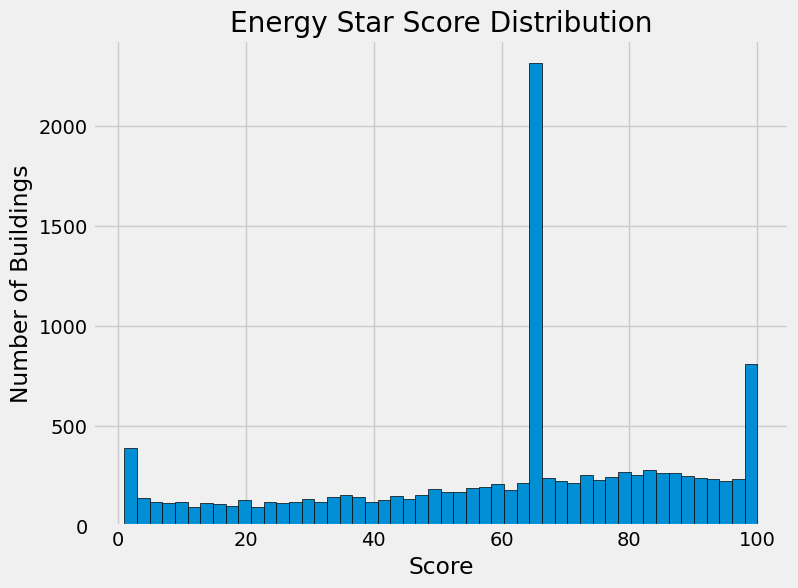

In [21]:
# Rename the 'ENERGY STAR Score' column to 'score'
data_cleaned = data_cleaned.rename(columns = {'ENERGY STAR Score': 'score'})

# Set the plot style
plt.style.use('fivethirtyeight')

# Plot a histogram for the 'score' column
plt.figure(figsize=(8, 6))  # Set the figure size
plt.hist(data_cleaned['score'].dropna(), bins=50, edgecolor='black')  # Plot histogram with 30 bins

# Labeling the axes and title
plt.xlabel('Score')
plt.ylabel('Number of Buildings')
plt.title('Energy Star Score Distribution')

# Show the plot
plt.show()


Our first plot has already revealed some surprising (and suspicious) information! 
What interesting pint do we understand from this plot? (HINT: refer to score definition and pdf)\
answer:\
This large spike could suggest data issues, such as scores being assigned in a uniform way, or standardized rounding for reporting purposes. It might be helpful to look further into the score definition and the method of calculation to understand why this score is so common.


To contrast the Energy Star Score, we can look at the Energy Use Intensity (EUI), which is the total energy use divided by the square footage of the building. Here the energy usage is not self-reported, so this could be a more objective measure of the energy efficiency of a building. Moreover, this is not a percentile rank, so the absolute values are important and we would expect them to be approximately normally distributed with perhaps a few outliers on the low or high end. 

Text(0.5, 1.0, 'Site EUI Distribution')

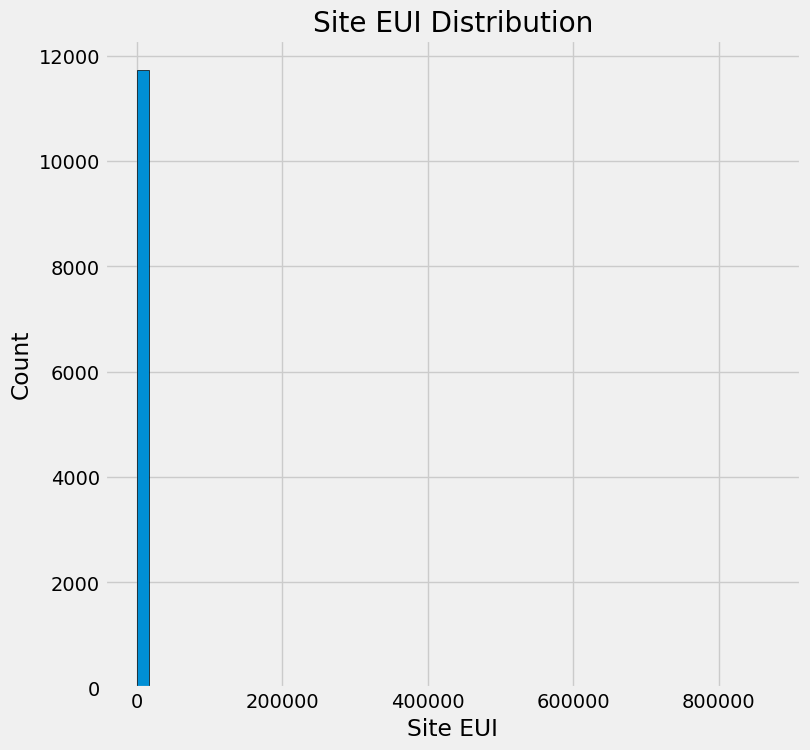

In [25]:
# Histogram Plot of Site EUI
figsize(8, 8)
plt.hist(data_cleaned['Site EUI (kBtu/ft²)'].dropna(), bins = 50, edgecolor = 'black')
plt.xlabel('Site EUI')
plt.ylabel('Count')
plt.title('Site EUI Distribution')

Well it seems we have another problem: outliers!
The graph is incredibly skewed because of the presence of a few buildings with very high scores. It looks like we will have to take a slight detour to deal with the outliers. Let's look at the stats for this feature.

In [26]:
data_cleaned['Site EUI (kBtu/ft²)'].describe()

count     11746.000000
mean        277.274264
std        8547.276458
min           0.000000
25%          62.100000
50%          78.500000
75%          97.200000
max      869265.000000
Name: Site EUI (kBtu/ft²), dtype: float64

How can we understand the existence of outlier from this information?\
answer:\
Based on the statistical results and histogram, there is an issue with outliers. The large difference between the maximum (869265) and minimum (0), the high standard deviation (8607.18), and the wide dispersion of the data indicate the presence of abnormal values. To identify these values more accurately, methods like Box Plot or statistical techniques such as IQR or z-score can be used.


__Find the one building (outlier) which is very different from the others__

To identify a building that is very different from other buildings as an outlier, we can use outlier values ​​(such as maximum and minimum). We can also use IQR (Interquartile Range) or Z-Score for more precise identification.

In [28]:
# Z-Score method
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(data_cleaned['Site EUI (kBtu/ft²)'].dropna()))
outlier_index_zscore = np.argmax(z_scores)  # Find the index of the outlier with highest Z-score

# IQR method
Q1 = data_cleaned['Site EUI (kBtu/ft²)'].quantile(0.25)
Q3 = data_cleaned['Site EUI (kBtu/ft²)'].quantile(0.75)
IQR = Q3 - Q1
outliers = data_cleaned[(data_cleaned['Site EUI (kBtu/ft²)'] < (Q1 - 1.5 * IQR)) | (data_cleaned['Site EUI (kBtu/ft²)'] > (Q3 + 1.5 * IQR))]

# Prepare the output text
output_text = f"Outliers based on Z-Score method (highest Z-score):\n{data_cleaned.iloc[outlier_index_zscore]}\n\nOutliers based on IQR method:\n{outliers}"

# Save to a text file
file_path = "outliers_results_with_text.txt"
with open(file_path, "w") as file:
    file.write(output_text)

# Provide the file path
print(f"Outliers results saved to: {file_path}")


Outliers results saved to: outliers_results_with_text.txt



### Removing Outliers

When we remove outliers, we want to be careful that we are not throwing away measurements just because they look strange. They may be the result of actual phenomenon that we should further investigate. When removing outliers, I try to be as conservative as possible, using the definition of an [extreme outlier](https://people.richland.edu/james/lecture/m170/ch03-pos.html): 

* On the low end, an extreme outlier is below  $\text{First Quartile} -3 * \text{Interquartile Range}$
* On the high end, an extreme outlier is above $\text{Third Quartile} + 3 * \text{Interquartile Range}$

In this case, I will only remove the single outlying point and see how the distribution looks.

In [29]:
# Calculate first and third quartile (Q1 and Q3)
first_quartile = data_cleaned['Site EUI (kBtu/ft²)'].quantile(0.25)
third_quartile = data_cleaned['Site EUI (kBtu/ft²)'].quantile(0.75)

# Interquartile range (IQR)
iqr = third_quartile - first_quartile

# Remove extreme outliers (outside the range of Q1 - 3*IQR and Q3 + 3*IQR)
data_out = data_cleaned[(data_cleaned['Site EUI (kBtu/ft²)'] > (first_quartile - 3 * iqr)) & 
                    (data_cleaned['Site EUI (kBtu/ft²)'] < (third_quartile + 3 * iqr))]

# Checking the number of rows before and after removing outliers
print(f"Original data size: {data_cleaned.shape[0]}")
print(f"Data size after removing outliers: {data_out.shape[0]}")


Original data size: 11746
Data size after removing outliers: 11475


Text(0.5, 1.0, 'Site EUI Distribution')

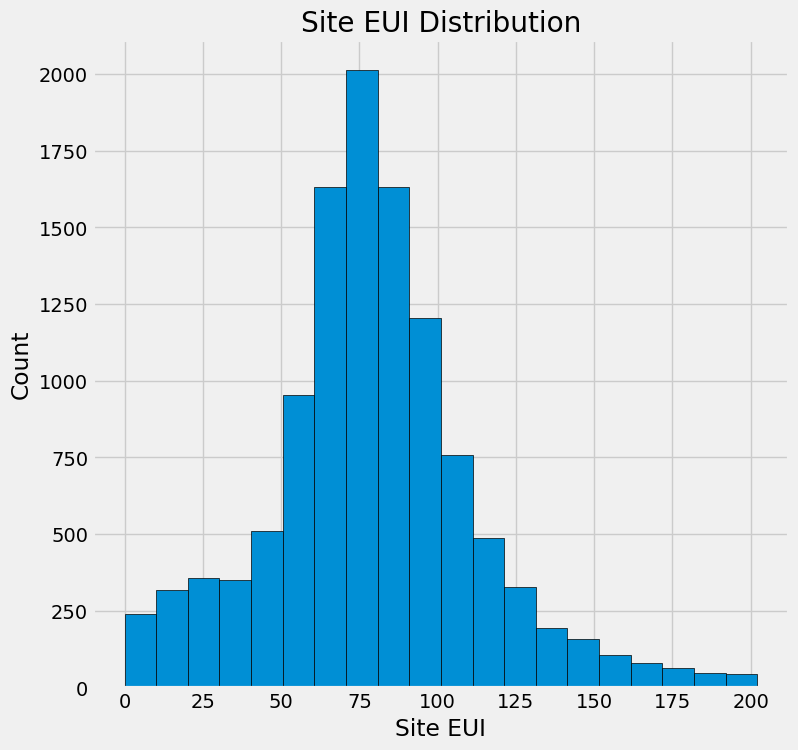

In [30]:
# Histogram Plot of Site EUI
figsize(8, 8)
plt.hist(data_out['Site EUI (kBtu/ft²)'].dropna(), bins = 20, edgecolor = 'black')
plt.xlabel('Site EUI')
plt.ylabel('Count')
plt.title('Site EUI Distribution')

After removing the outliers, we can get back to the analysis.

This plot looks a little less suspicious and is close to normally distributed with a long tail on the right side (it has a positive skew). 

Although this might be a more objective measure, our goal is still to predict the Energy Star Score, so we will move back to examining that variable. 

## Looking for Relationships

In order to look at the effect of categorical variables on the score, we can make a [density plot](https://datavizcatalogue.com/methods/density_plot.html) colored by the value of the categorical variable. Density plots also show the distribution of a single variable and can be thought of as a smoothed histogram. 
If we color the density curves by a categorical variable, this will shows us how the distribution changes based on the class. 

The first plot we will make shows the distribution of scores by the property type. In order to not clutter the plot, we will limit the graph to building types that have more than 100 observations in the dataset. 

In [32]:
# Create a list of buildings with more than 100 measurements
types = data_out.dropna(subset=['score'])
types = types['Largest Property Use Type'].value_counts()
types = list(types[types.values > 100].index)

C:\Users\niush\AppData\Local\Temp\ipykernel_2988\1453031711.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset['score'].dropna(),


Text(0.5, 1.0, 'Density Plot of Energy Star Scores by Building Type')

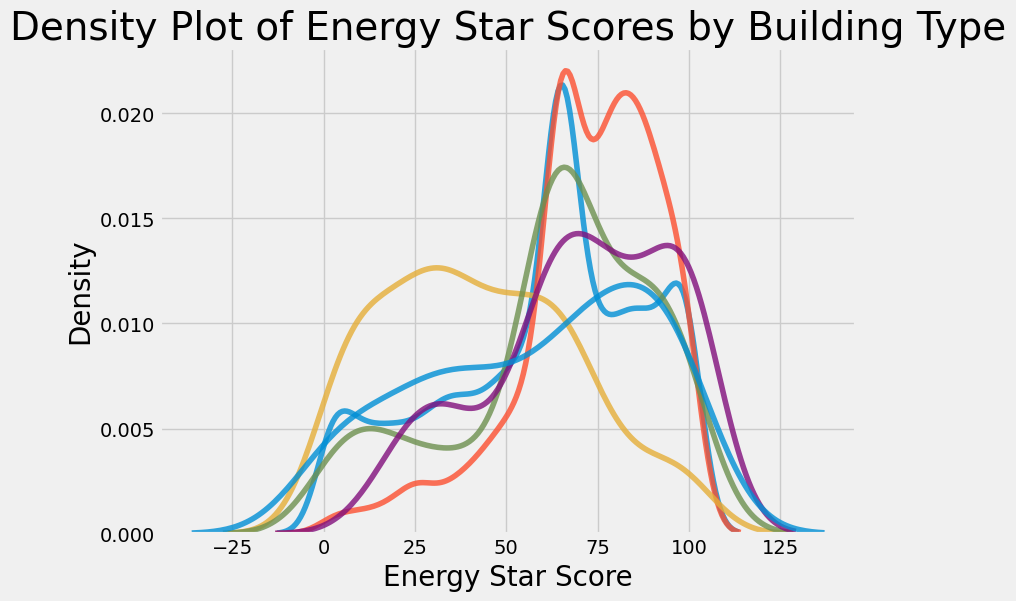

In [35]:
# Plot of distribution of scores for building categories
figsize(8, 6)

# Plot each building
for b_type in types:
    # Select the building type
    subset = data_out[data_out['Largest Property Use Type'] == b_type]
    
    # Density plot of Energy Star scores
    sns.kdeplot(subset['score'].dropna(),
               label = b_type, fill = False, alpha = 0.8)
    
# label the plot
plt.xlabel('Energy Star Score', size = 20)
plt.ylabel('Density', size = 20)
plt.title('Density Plot of Energy Star Scores by Building Type', size = 28)

It can be seen that the `Largest Property Use Type` or the building type affects our wanted `score` (the negative scores on the graph are an artifact of the [kernel density estimation](https://chemicalstatistician.wordpress.com/2013/06/09/exploratory-data-analysis-kernel-density-estimation-in-r-on-ozone-pollution-data-in-new-york-and-ozonopolis/) procedure).


How can we convert this categorical variable to a useful form of data for our Model?\
answer:\
To convert the 'Largest Property Use Type' categorical variable into a usable format for a machine learning model, we can use encoding techniques like:

Label Encoding: Assigns a numeric value to each category, but can introduce unwanted ordinal relationships.\
One-Hot Encoding: Creates binary columns for each category, best for non-ordinal categories.\
Target Encoding: Replaces categories with the mean of the target variable, useful for high-cardinality categories.\
For 'Largest Property Use Type', One-Hot Encoding is the best option to avoid introducing false relationships.



To examine another categorical variable, borough, we can make the same graph, but this time colored by the borough.

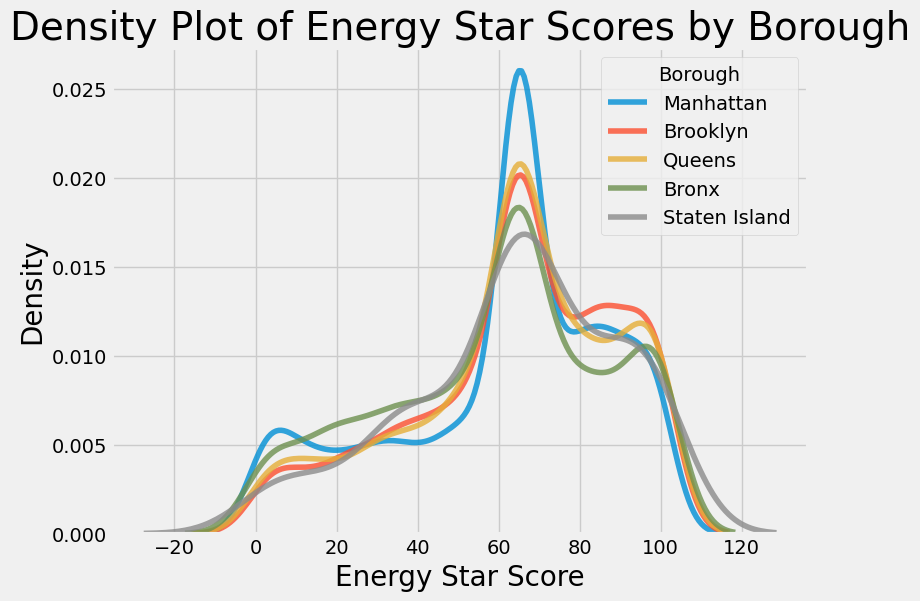

In [37]:
# Create a list of boroughs with more than 100 observations
boroughs = data_out.dropna(subset=['score'])
boroughs = boroughs['Borough'].value_counts()
boroughs = list(boroughs[boroughs.values > 100].index)

# Plot of distribution of scores for each borough
figsize(8, 6)

# Plot each borough
for borough in boroughs:
    # Select the borough
    subset = data_out[data_out['Borough'] == borough]
    
    # Density plot of Energy Star scores for each borough
    sns.kdeplot(subset['score'].dropna(),
                label = borough, fill = False, alpha = 0.8)
    
# Label the plot
plt.xlabel('Energy Star Score', size = 20)
plt.ylabel('Density', size = 20)
plt.title('Density Plot of Energy Star Scores by Borough', size = 28)
plt.legend(title='Borough')
plt.show()


How is boroughs different from building type?\
answer:\
Borough represents the geographical location (such as Manhattan, Brooklyn), whereas building type refers to the purpose or use of the building (such as hospital or office).

Is it useful to use this column as well?\
answer:\
Yes, using Borough can be useful as it can highlight regional impacts on energy consumption. This information can help the model better simulate geographical differences in energy usage.

## Correlations between Features and Target

In order to quantify correlations between the features (variables) and the target, use the Pearson similarity

In [39]:
# Filter out non-numeric columns before calculating correlation
numeric_data = data_out.select_dtypes(include=[np.number])

# Calculate the Pearson correlation for numeric columns
correlations_data = numeric_data.corr()

# Sort the correlations in descending order (for positive correlations)
positive_correlations = correlations_data['score'].sort_values(ascending=False)

# Print the most negative correlations (with lowest values)
print("Most negative correlations:\n", positive_correlations.tail(15), '\n')

# Print the most positive correlations (with highest values)
print("Most positive correlations:\n", positive_correlations.head(15))


Most negative correlations:
 Indirect GHG Emissions (Metric Tons CO2e)                    -0.033705
Weather Normalized Site Electricity (kWh)                    -0.039556
Electricity Use - Grid Purchase (kBtu)                       -0.040654
Property Id                                                  -0.043073
Total GHG Emissions (Metric Tons CO2e)                       -0.088513
Year Built                                                   -0.107342
Weather Normalized Site Natural Gas Use (therms)             -0.110455
Natural Gas Use (kBtu)                                       -0.111605
Direct GHG Emissions (Metric Tons CO2e)                      -0.129002
Weather Normalized Site Natural Gas Intensity (therms/ft²)   -0.293814
Weather Normalized Site Electricity Intensity (kWh/ft²)      -0.301603
Weather Normalized Source EUI (kBtu/ft²)                     -0.527017
Source EUI (kBtu/ft²)                                        -0.550411
Weather Normalized Site EUI (kBtu/ft²)          

There are several strong negative correlations between the features and the target. The most negative correlations with the score are the different categories of Energy Use Intensity (EUI), `Site EUI (kBtu/ft²)` and  `Weather Normalized Site EUI (kBtu/ft²)` (these vary slightly in how they are calculated). The EUI is the amount of energy used by a building divided by the square footage of the buildings and is meant to be a measure of the efficiency of a building with a lower score being better. Intuitively, these correlations then make sense: as the EUI increases, the Energy Star Score tends to decrease. 

To account for possible non-linear relationships, You can take square root and natural log transformations of the features and then calculate the correlation coefficients with the score. 

In the following code, we take log and square root transformations of the numerical variables, the correlations between all of the features and the score, and display the top 15 most positive and top 15 most negative correlations.

Remember to transform useful Categorical Columns to numerical form!

In [40]:
import numpy as np
import pandas as pd

# Select the numeric columns
numeric_subset = data_out.select_dtypes('number')

# Create columns with square root and log of numeric columns
for col in numeric_subset.columns:
    # Skip the Energy Star Score column
    if col == 'score':
        continue
    else:
        # Apply square root transformation
        numeric_subset[f'{col}_sqrt'] = np.sqrt(numeric_subset[col])

        # Apply log transformation (adding a small constant to avoid log(0) issues)
        numeric_subset[f'{col}_log'] = np.log(numeric_subset[col] + 1)

# Select the categorical columns (choose informative categorical columns based on your data)
categorical_subset = data_out[['Largest Property Use Type', 'Borough']]  # Example columns

# Transform categorical columns to numerical (using pd.get_dummies for one-hot encoding)
categorical_subset = pd.get_dummies(categorical_subset, drop_first=True)

# Join the two dataframes using concat
features = pd.concat([numeric_subset, categorical_subset], axis=1)

# Drop buildings without an energy star score
features = features.dropna(subset=['score'])

# Find correlations with the score
correlations = features.corr()['score'].dropna().sort_values()

# Print the most negative correlations
print("Most negative correlations:\n", correlations.head(15), '\n')

# Print the most positive correlations
print("Most positive correlations:\n", correlations.tail(15))


Most negative correlations:
 Site EUI (kBtu/ft²)                                            -0.636238
Site EUI (kBtu/ft²)_sqrt                                       -0.602197
Weather Normalized Site EUI (kBtu/ft²)                         -0.596621
Source EUI (kBtu/ft²)_sqrt                                     -0.569046
Weather Normalized Site EUI (kBtu/ft²)_sqrt                    -0.560011
Source EUI (kBtu/ft²)                                          -0.550411
Weather Normalized Source EUI (kBtu/ft²)_sqrt                  -0.539547
Weather Normalized Source EUI (kBtu/ft²)                       -0.527017
Site EUI (kBtu/ft²)_log                                        -0.512304
Source EUI (kBtu/ft²)_log                                      -0.507681
Weather Normalized Source EUI (kBtu/ft²)_log                   -0.474005
Weather Normalized Site EUI (kBtu/ft²)_log                     -0.471322
Weather Normalized Site Electricity Intensity (kWh/ft²)_log    -0.365054
Weather Normalized Sit

In [41]:
# Display most negative correlations
correlations.head(15)

Site EUI (kBtu/ft²)                                            -0.636238
Site EUI (kBtu/ft²)_sqrt                                       -0.602197
Weather Normalized Site EUI (kBtu/ft²)                         -0.596621
Source EUI (kBtu/ft²)_sqrt                                     -0.569046
Weather Normalized Site EUI (kBtu/ft²)_sqrt                    -0.560011
Source EUI (kBtu/ft²)                                          -0.550411
Weather Normalized Source EUI (kBtu/ft²)_sqrt                  -0.539547
Weather Normalized Source EUI (kBtu/ft²)                       -0.527017
Site EUI (kBtu/ft²)_log                                        -0.512304
Source EUI (kBtu/ft²)_log                                      -0.507681
Weather Normalized Source EUI (kBtu/ft²)_log                   -0.474005
Weather Normalized Site EUI (kBtu/ft²)_log                     -0.471322
Weather Normalized Site Electricity Intensity (kWh/ft²)_log    -0.365054
Weather Normalized Site Electricity Intensity (kWh/

In [42]:
# Display most positive correlations
correlations.tail(15)

Largest Property Use Type - Gross Floor Area (ft²)                 0.016584
Order_sqrt                                                         0.017016
Property GFA - Self-Reported (ft²)_sqrt                            0.018706
Largest Property Use Type - Gross Floor Area (ft²)_sqrt            0.020040
Property GFA - Self-Reported (ft²)_log                             0.020973
Largest Property Use Type_Retail Store                             0.022487
Largest Property Use Type - Gross Floor Area (ft²)_log             0.023979
Largest Property Use Type_Supermarket/Grocery Store                0.024875
Order                                                              0.025874
Borough_Queens                                                     0.026288
Largest Property Use Type_Residence Hall/Dormitory                 0.032196
Largest Property Use Type_Hospital (General Medical & Surgical)    0.041589
Borough_Brooklyn                                                   0.042365
Largest Prop

After transforming the features, the strongest relationships are still those related to Energy Use Intensity (EUI). The log and square root transformations do not seem the have resulted in any stronger relationships. There are no strong positive linear relationships although we do see that a building type of office (`Largest Property Use Type_Office`) is slightly positively correlated with the score. This variable is a one-hot encoded representation of the categorical variables for building type.

We can use these correlations in order to perform feature selection (coming up in a little bit). Right now, let's graph the most significant correlation (in terms of absolute value) in the dataset which is `Site EUI (kBtu/ft^2)`. We can color the graph by the building type to show how that affects the relationship. 

## Two-Variable Plots

In order to visualize the relationship between two variables, we use a scatterplot. We can also include additional variables using aspects such as color of the markers or size of the markers. Here we will plot two numeric variables against one another and use color to represent a third categorical variable.

<Figure size 1200x1000 with 0 Axes>

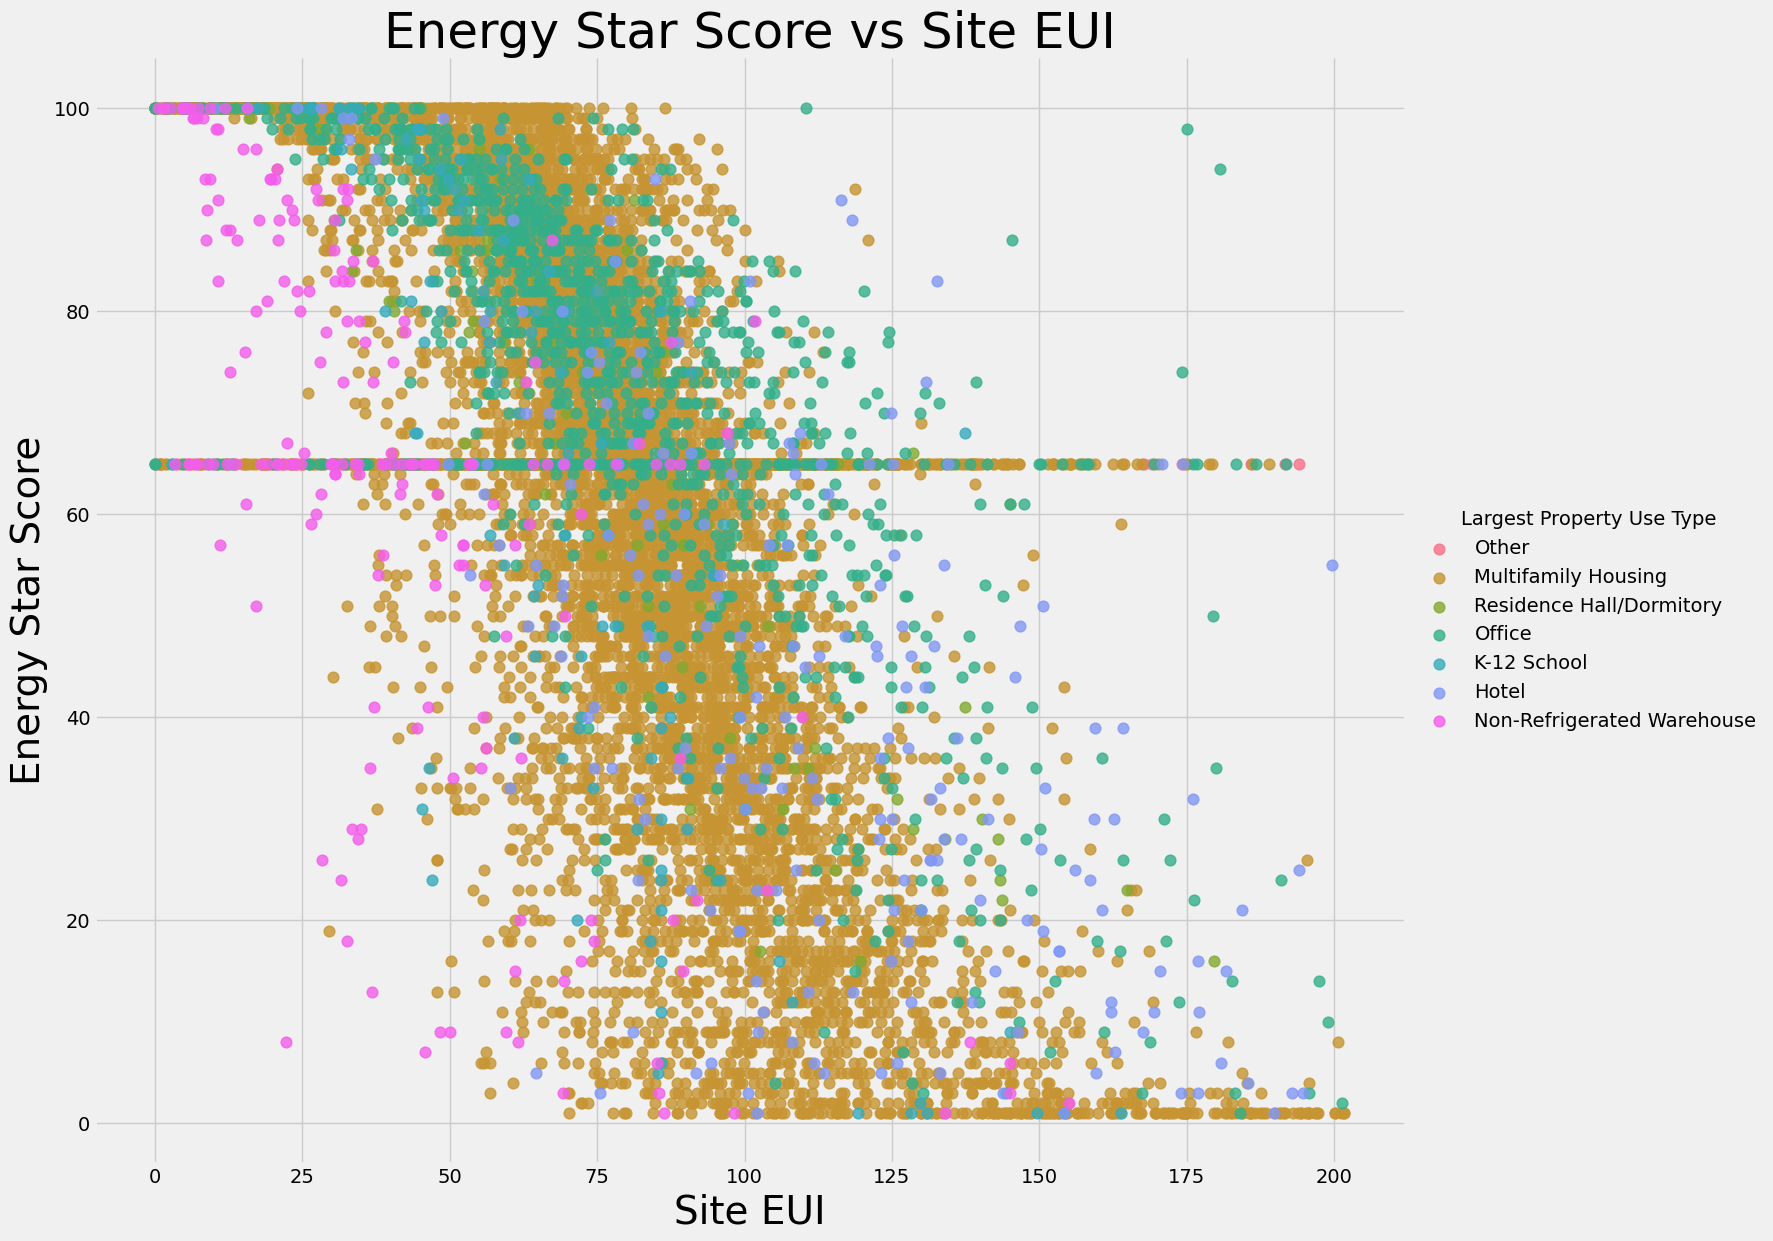

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(12, 10))

# Extract the building types
features['Largest Property Use Type'] = data_out.dropna(subset=['score'])['Largest Property Use Type']

# Limit to building types with more than 100 observations (from previous code)
features = features[features['Largest Property Use Type'].isin(types)]

# Use seaborn to plot a scatterplot of Score vs Site EUI
sns.lmplot(x='Site EUI (kBtu/ft²)', y='score', 
           hue='Largest Property Use Type', data=features,
           scatter_kws={'alpha': 0.8, 's': 60}, fit_reg=False,
           height=12, aspect=1.2)

# Plot labeling
plt.xlabel("Site EUI", size=28)
plt.ylabel('Energy Star Score', size=28)
plt.title('Energy Star Score vs Site EUI', size=36)

plt.show()


There is a clear negative relationship between the Site EUI and the score. The relationship is not perfectly linear (it looks with a correlation coefficient of -0.7, but it does look like this feature will be important for predicting the score of a building. 

### Pairs Plot

As a final exercise for exploratory data analysis, we can make a pairs plot between several different variables. The Pairs Plot is a great way to examine many variables at once as it shows scatterplots between pairs of variables and histograms of single variables on the diagonal. 

Using the seaborn `PairGrid` function, we can map different plots on to the three aspects of the grid. The upper triangle will have scatterplots, the diagonal will show histograms, and the lower triangle will show both the correlation coefficient between two variables and a 2-D kernel density estimate of the two variables. 

In [ ]:
plot_data = features[['score', 'Site EUI (kBtu/ft²)', 
                      'Weather Normalized Source EUI (kBtu/ft²)', 
                      'log_Total GHG Emissions (Metric Tons CO2e)']]

# Replace inf with nan to avoid issues during plotting
plot_data = plot_data.replace({np.inf: np.nan, -np.inf: np.nan})

# Rename columns for clarity
plot_data = plot_data.rename(columns = {'Site EUI (kBtu/ft²)': 'Site EUI', 
                                        'Weather Normalized Source EUI (kBtu/ft²)': 'Weather Norm EUI',
                                        'log_Total GHG Emissions (Metric Tons CO2e)': 'log GHG Emissions'})

# Drop rows with missing values
plot_data = plot_data.dropna()

# Function to calculate the correlation coefficient between two columns
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate("r = {:.2f}".format(r),
                xy=(.2, .8), xycoords=ax.transAxes,
                size=20)

# Create the pairgrid object
grid = sns.PairGrid(data=plot_data, height=3)

# Upper triangle: scatter plot
grid.map_upper(plt.scatter, color='red', alpha=0.6)

# Diagonal: histogram
grid.map_diag(plt.hist, color='red', edgecolor='black')

# Lower triangle: correlation and density plot
grid.map_lower(corr_func)
grid.map_l


To interpret the relationships in the plot, we can look for where the variables in one row intersect with the variables in one column. For example, to find the relationship between score and the log of GHG Emissions, we look at the score column and find the log GHG Emissions row. At the intersection (the lower left plot) we see that the score has a -0.35 correlation coefficient with this varible. If we look at the upper right plot, we can see a scatterplot of this relationship. 

# Feature Engineering and Selection

Now that we have explored the trends and relationships within the data, we can work on engineering a set of features for our models. We can use the results of the EDA to inform this feature engineering. In particular, we learned the following from EDA which can help us in engineering/selecting features:

* The score distribution varies by building type and to a lesser extent by borough. Although we will focus on numerical features, we should also include these two categorical features in the model. 


Did taking the log transformation of features result in significant increases in the linear correlations between features and the score?
asw:


Before we get any further, we should define what feature engineering and selection are! These definitions are informal and have considerable overlap, but I like to think of them as two separate processes:

* __[Feature Engineering](https://machinelearningmastery.com/discover-feature-engineering-how-to-engineer-features-and-how-to-get-good-at-it/)__: The process of taking raw data and extracting or creating new features that allow a machine learning model to learn a mapping beween these features and the target. This might mean taking transformations of variables, such as we did with the log and square root, or one-hot encoding categorical variables so they can be used in a model. Generally, I think of feature engineering as __adding__ additional features derived from the raw data.
* __[Feature Selection](https://machinelearningmastery.com/an-introduction-to-feature-selection/)__: The process of choosing the most relevant features in your data. "Most relevant" can depend on many factors, but it might be something as simple as the highest correlation with the target, or the features with the [most variance](http://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html). In feature selection, we remove features that do not help our model learn the relationship between features and the target. This can help the model generalize better to new data and results in a more interpretable model. Generally, I think of feature selection as __subtracting__ features so we are left with only those that are most important.

[Feature engineering and selection](https://www.featurelabs.com/blog/secret-to-data-science-success/) often has the highest returns on time invested in a machine learning problem. It can take quite a while to get right, but is often more important than the exact algorithm and hyperparameters used for the model. If we don't feed the model the correct data, then we are setting it up to fail and we should not expect it to learn! 

In this project, we will take the following steps for feature engineering:

* Select only the numerical variables and categorical variables 
* Add in the log transformation of the numerical variables

For feature selection, we will do the following:

* Remove [collinear features](https://statinfer.com/204-1-9-issue-of-multicollinearity-in-python/)



The following code selects the numeric features, adds in log transformations of all the numeric features, selects and one-hot encodes the categorical features, and joins the sets of features together. 

In [78]:
# Copy the original data
features = data_out.copy()

# Select the numeric columns (excluding the target variable 'score')
numeric_subset = data_out.select_dtypes(include=[np.number]).drop(columns=['score'])

# Create columns with log of numeric columns
for col in numeric_subset.columns:
    features['log_' + col] = np.log(numeric_subset[col] + 1)  # Adding 1 to avoid log(0)

# Select the categorical columns (assuming we want to include columns such as 'Largest Property Use Type')
categorical_subset = data_out[['Largest Property Use Type', 'Borough']]  # Replace with your actual categorical columns

# Apply one-hot encoding to the categorical columns
categorical_subset = pd.get_dummies(categorical_subset, drop_first=True)

# Add numeric columns (log-transformed) and categorical columns to the existing 'features'
features = features.join(numeric_subset, rsuffix='_numeric')  # Add numeric columns with '_numeric' suffix
features = features.join(categorical_subset)  # Add categorical columns

# Output the shape of the features DataFrame
print(features.shape)


(11475, 135)


## Remove Collinear Features

Highly [collinear features](http://psychologicalstatistics.blogspot.com/2013/11/multicollinearity-and-collinearity-in.html) have a significant correlation coefficent between them. 

Could plot and you give an example of two collinear related features? \
answer:\
Collinearity occurs when two features in a dataset are highly correlated. It means one feature can be predicted from the other with high accuracy. For example, Total GHG Emissions (Metric Tons CO2e) and Direct GHG Emissions (Metric Tons CO2e) might be collinear. To detect collinearity, you can use a scatter plot and check the correlation coefficient. A high correlation (close to 1 or -1) indicates strong collinearity.



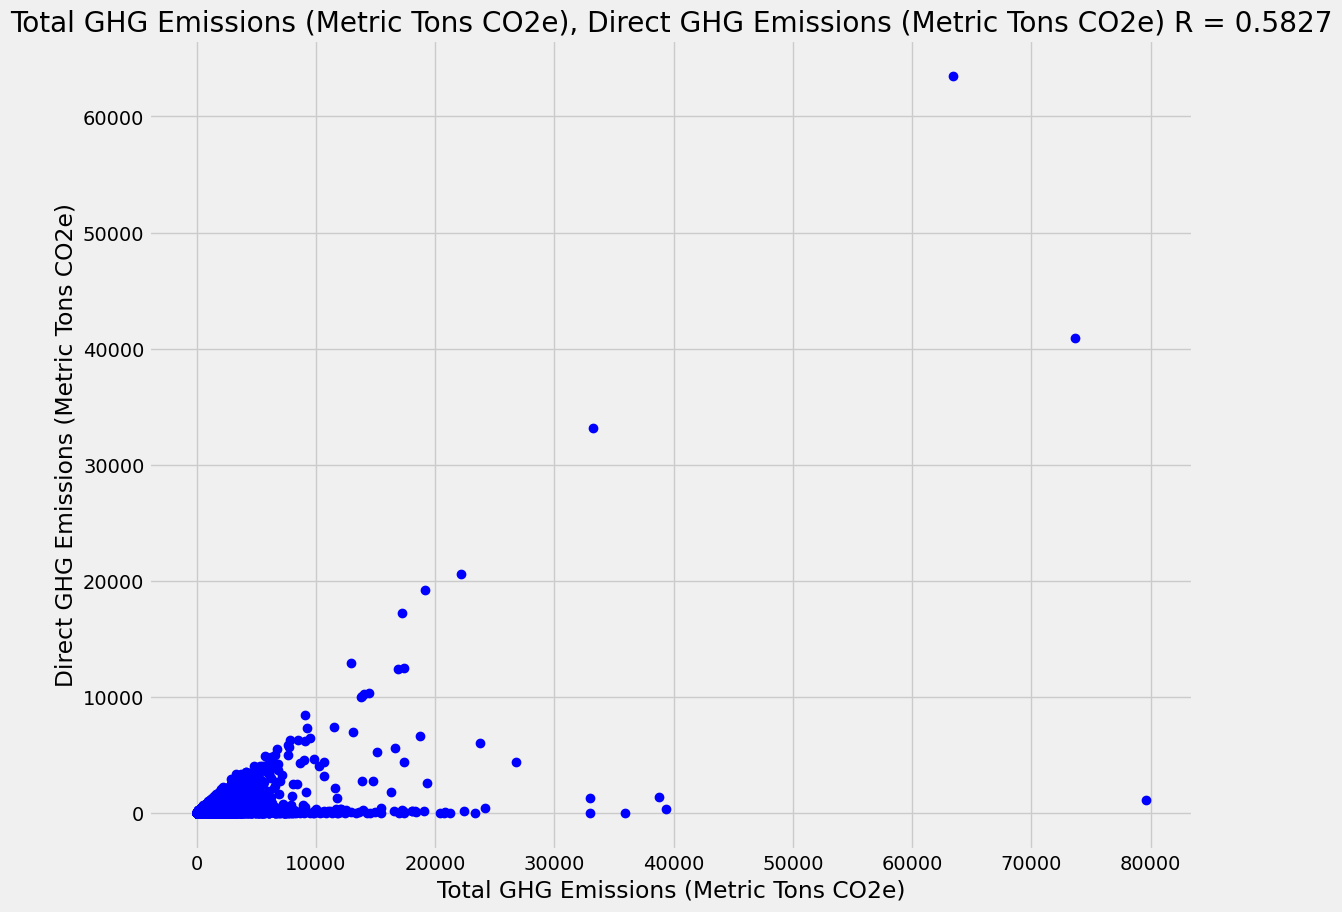

In [80]:
# Example columns for collinearity, replace with actual column names
col_1 = 'Total GHG Emissions (Metric Tons CO2e)'  # Example column
col_2 = 'Direct GHG Emissions (Metric Tons CO2e)'  # Example column

# Select the columns and drop any rows with missing values
plot_data = data_out[[col_1, col_2]].dropna()

# Plot the data
plt.plot(plot_data[col_1], plot_data[col_2], 'bo')
plt.xlabel(col_1)
plt.ylabel(col_2)

# Calculate the correlation coefficient
correlation = np.corrcoef(plot_data[col_1], plot_data[col_2])[0][1]
plt.title(f'{col_1}, {col_2} R = {correlation:.4f}')

# Show the plot
plt.show()

While variables in a dataset are usually correlated to a small degree, highly collinear variables can be redundant in the sense that we only need to retain one of the features to give our model the necessary information.

Removing collinear features is a method to reduce model complexity by decreasing the number of features and can help to increase model generalization.  It can also help us to interpret the model because we only have to worry about a single variable, such as EUI, rather than how both EUI and weather normalized EUI affect the score. 

There are a number of methods for removing collinear features, such as using the [Variance Inflation Factor](http://www.statisticshowto.com/variance-inflation-factor/). We will use a simpler metric, and remove features that have a correlation coefficient above a certain threshold with each other (not with the score because we want variables that are highly correlated with the score!) For a more thorough discussion of removing collinear variables, check out [this notebook on Kaggle](https://www.kaggle.com/robertoruiz/dealing-with-multicollinearity/code).

The following code removes the collinear features based on a threshold we select for the correlation coefficients by removing one of the two features that are compared. It also prints the correlations that it removes so we can see the effect of adjusting the threshold. We will use a threshold of 0.6 which removes one of a pair of features if the correlation coefficient between the features exceeds this value. 


In [81]:
features.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Postal Code,Street Number,Street Name,Borough,DOF Gross Floor Area,Primary Property Type - Self Selected,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,Metered Areas (Energy),score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),...,Largest Property Use Type_Other - Education,Largest Property Use Type_Other - Entertainment/Public Assembly,Largest Property Use Type_Other - Lodging/Residential,Largest Property Use Type_Other - Mall,Largest Property Use Type_Other - Public Services,Largest Property Use Type_Other - Recreation,Largest Property Use Type_Other - Services,Largest Property Use Type_Other - Specialty Hospital,Largest Property Use Type_Outpatient Rehabilitation/Physical Therapy,Largest Property Use Type_Parking,Largest Property Use Type_Performing Arts,Largest Property Use Type_Pre-school/Daycare,Largest Property Use Type_Refrigerated Warehouse,"Largest Property Use Type_Repair Services (Vehicle, Shoe, Locksmith, etc.)",Largest Property Use Type_Residence Hall/Dormitory,Largest Property Use Type_Residential Care Facility,Largest Property Use Type_Restaurant,Largest Property Use Type_Retail Store,Largest Property Use Type_Self-Storage Facility,Largest Property Use Type_Senior Care Community,Largest Property Use Type_Social/Meeting Hall,Largest Property Use Type_Strip Mall,Largest Property Use Type_Supermarket/Grocery Store,Largest Property Use Type_Urgent Care/Clinic/Other Outpatient,Largest Property Use Type_Wholesale Club/Supercenter,Largest Property Use Type_Worship Facility,Borough_Brooklyn,Borough_Manhattan,Borough_Queens,Borough_Staten Island
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,10032,3975,BROADWAY,Manhattan,152765.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),231342.0,1924,1,100,Whole Building,65.0,78.5,82.5,5.3,0.5,129.4,4103962.15,44455.25,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,10032,161,FT WASHINGTON AVENUE,Manhattan,891040.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),1305748.0,1971,1,100,Whole Building,65.0,78.5,82.5,5.3,0.5,129.4,4103962.15,44455.25,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,5,4778288,Neuro Institute,28400,NYP Columbia (West Campus),1021390085,1-02139-0085,1063403,710 West 168th Street,10032,193,FT WASHINGTON AVENUE,Manhattan,211400.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),179694.0,1932,1,100,Whole Building,65.0,78.5,82.5,5.3,0.5,129.4,4103962.15,44455.25,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
6,7,4778352,Annex Building & Garage,28402,NYP Cornell (East Campus),1014820040,1-01482-0040,1081252,523 East 70th St,10021,512,EAST 71 STREET,Manhattan,245000.0,Mixed Use Property,Other,O

In [84]:
def remove_collinear_features(x, threshold):
    '''
    Objective:
        Remove collinear features in a dataframe with a correlation coefficient
        greater than the threshold. Removing collinear features can help a model
        to generalize and improves the interpretability of the model.
        
    Inputs: 
        threshold: any features with correlations greater than this value are removed
    
    Output: 
        dataframe that contains only the non-highly-collinear features
    '''
    
    # Don't want to remove correlations with Energy Star Score
    y = x['score']
    x = x.drop(columns = ['score'])
    
    # Select only the numeric columns for correlation calculation
    numeric_x = x.select_dtypes(include=[np.number])
    
    # Calculate the correlation matrix on the numeric columns
    corr_matrix = numeric_x.corr()
    iters = range(len(corr_matrix.columns) - 1)
    drop_cols = []

    # Iterate through the correlation matrix and compare correlations
    for i in iters:
        for j in range(i):
            # If correlation is greater than the threshold, add the column to be dropped
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                drop_cols.append(colname)
                print(f'Removing collinear feature pair: {corr_matrix.columns[i]} and {corr_matrix.columns[j]}')
    
    # Remove duplicates from the drop_cols list, keeping unique columns
    drops = set(drop_cols)
    x = x.drop(columns = drops)
    
    # Drop the specified columns that we want to exclude manually
    x = x.drop(columns = ['Weather Normalized Site EUI (kBtu/ft²)', 
                          'Water Use (All Water Sources) (kgal)',
                          'log_Water Use (All Water Sources) (kgal)',
                          'Largest Property Use Type - Gross Floor Area (ft²)'])
    
    # Add the target column (Energy Star Score) back into the dataset
    x['score'] = y
               
    return x


In [85]:
correlation_threshold = 0.6
features = remove_collinear_features(features, correlation_threshold)

print(features.shape)

Removing collinear feature pair: Largest Property Use Type - Gross Floor Area (ft²) and DOF Gross Floor Area
Removing collinear feature pair: Weather Normalized Site EUI (kBtu/ft²) and Site EUI (kBtu/ft²)
Removing collinear feature pair: Weather Normalized Source EUI (kBtu/ft²) and Site EUI (kBtu/ft²)
Removing collinear feature pair: Weather Normalized Source EUI (kBtu/ft²) and Weather Normalized Site EUI (kBtu/ft²)
Removing collinear feature pair: Weather Normalized Source EUI (kBtu/ft²) and Weather Normalized Site Electricity Intensity (kWh/ft²)
Removing collinear feature pair: Weather Normalized Site Natural Gas Use (therms) and Natural Gas Use (kBtu)
Removing collinear feature pair: Weather Normalized Site Electricity (kWh) and Electricity Use - Grid Purchase (kBtu)
Removing collinear feature pair: Total GHG Emissions (Metric Tons CO2e) and DOF Gross Floor Area
Removing collinear feature pair: Total GHG Emissions (Metric Tons CO2e) and Largest Property Use Type - Gross Floor Area (

In [86]:
# Remove any columns with all na values
features  = features.dropna(axis=1, how = 'all')
features.shape

(11475, 84)

Our final dataset now has 64 features (one of the columns is the target). This is still quite a few, but mostly it is because we have one-hot encoded the categorical variables. Moreover, while a large number of features may be problematic for models such as linear regression, models such as the random forest perform implicit feature selection and automatically determine which features are important during traning. There are other feature selection steps to take, but for now we will keep all the features we have and see how the model performs.

#### Additional Feature Selection

There are plenty of more methods for [feature selection](http://scikit-learn.org/stable/modules/feature_selection.html). Some popular methods include [principal components analysis (PCA)](http://www.cs.otago.ac.nz/cosc453/student_tutorials/principal_components.pdf) which transforms the features into a reduced number of dimensions that preserve the greatest variance, or [independent components analysis (ICA)](http://cs229.stanford.edu/notes/cs229-notes11.pdf) which aims to find the independent sources in a set of features. However, while these methods are effective at reducing the number of features, they create new features that have no physical meaning and hence make interpreting a model nearly impossible. 

These methods are very helpful for dealing with high-dimensional data and I would suggest [reading more on the topic](https://machinelearningmastery.com/feature-selection-machine-learning-python/) if you plan on dealing with machine learning problems! 

## Split Into Training and Testing Sets

In machine learning, we always need to separate our features into two sets:

1. __Training set__ which we provide to our model during training along with the answers so it can learn a mapping between the features and the target. 
2. __Testing set__ which we use to evaluate the mapping learned by the model. The model has never seen the answers on the testing set, but instead, must make predictions using only the features. As we know the true answers for the test set, we can then compare the test predictions to the true test targets to ghet an estimate of how well our model will perform when deployed in the real world. 

For our problem, we will first extract all the buildings without an Energy Star Score (we don't know the true answer for these buildings so they will not be helpful for training or testing). Then, we will split the buildings with an Energy Star Score into a testing set of 30% of the buildings, and a training set of 70% of the buildings. 

Splitting the data into a random training and testing set is simple using scikit-learn. We can set the random state of the split to ensure consistent results.

In [87]:
# Extract the buildings with no score and the buildings with a score
no_score = features[features['score'].isna()]
score = features[features['score'].notnull()]

print(no_score.shape)
print(score.shape)

(0, 84)
(11475, 84)


In [88]:
# Separate out the features and targets
features = score.drop(columns='score')
targets = pd.DataFrame(score['score'])

# Replace the inf and -inf with nan (required for later imputation)
features = features.replace({np.inf: np.nan, -np.inf: np.nan})

# Split into 70% training and 30% testing set
X, X_test, y, y_test = train_test_split(features, targets, test_size = 0.3, random_state = 42)

print(X.shape)
print(X_test.shape)
print(y.shape)
print(y_test.shape)

(8032, 83)
(3443, 83)
(8032, 1)
(3443, 1)


We have 1858 buildings with no score, 6622 buildings with a score in the training set, and 2839 buildings with a score in the testing set. We have one final step to take in this notebook: determining a naive baseline for our models to beat! 

# Establish a Baseline 

It's important to establish a naive baseline before we beginning making machine learning models. If the models we build cannot outperform a naive guess then we might have to admit that machine learning is not suited for this problem. This could be because we are not using the right models, because we need more data, or because there is a simpler solution that does not require machine learning. Establishing a baseline is crucial so we do not end up building a machine learning model only to realize we can't actually solve the problem.

For a regression task, a good naive baseline is to predict the median value of the target on the training set for all examples on the test set. This is simple to implement and sets a relatively low bar for our models: if they cannot do better than guessing the medin value, then we will need to rethink our approach. 

## Metric: Mean Absolute Error



In [89]:
# Function to calculate mean absolute error
def mae(y_true, y_pred):
    # Compute the absolute errors
    absolute_errors = abs(y_true - y_pred)
    
    # Compute and return the mean of the absolute errors
    return absolute_errors.mean()


Now we can make the median guess and evaluate it on the test set.

In [90]:
baseline_guess = np.median(y)

print('The baseline guess is a score of %0.2f' % baseline_guess)
print("Baseline Performance on the test set: MAE = %0.4f" % mae(y_test, baseline_guess))

The baseline guess is a score of 65.00
Baseline Performance on the test set: MAE = 20.6343


C:\Users\niush\AppData\Local\Temp\ipykernel_2988\1246975450.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Baseline Performance on the test set: MAE = %0.4f" % mae(y_test, baseline_guess))


This shows our average estimate on the test set is off by about 25 points. The scores are between 1 and 100 so this means the average error from a naive method if about 25%. The naive method of guessing the median training value provides us a low baseline for our models to beat! 

# Conclusions

In this notebook, we carried out the first three [steps of a machine learning](https://towardsdatascience.com/the-7-steps-of-machine-learning-2877d7e5548e?gi=30cd995093a9) problem:

1. Cleaned and formatted the raw data 
2. Performed an exploratory data analysis
3. Developed a set of features to train our model using feature engineering and feature selection

We also completed the crucial task of establishing a baseline metric so we can determine if our model is better than guessing! 



In [91]:
# Save the no scores, training, and testing data
no_score.to_csv('no_score.csv', index = False)
X.to_csv('training_features.csv', index = False)
X_test.to_csv('testing_features.csv', index = False)
y.to_csv('training_labels.csv', index = False)
y_test.to_csv('testing_labels.csv', index = False)